In [1]:
from pathlib import Path


def project_root() -> Path:
    """Resolve repo root (repo root, notebooks/, or other subfolders)."""
    cwd = Path.cwd().resolve()
    for d in [cwd, *cwd.parents]:
        km = d / "keras_models"
        if km.is_dir() and any(km.glob("*.keras")):
            return d
        if (d / ".git").exists() and (d / "results").is_dir():
            return d
    if (cwd / "datasets").is_dir() or (cwd / "results").is_dir():
        return cwd
    if (cwd.parent / "datasets").is_dir() or (cwd.parent / "results").is_dir():
        return cwd.parent
    return cwd


ROOT = project_root()


In [2]:
# =============================================================================
# Robustness Analysis — mCE and Relative mCE
# Baseline: MCUNet_Official
# =============================================================================
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path

# --- Register custom layer (required to load MCUNet_Official.keras) ---
@tf.keras.utils.register_keras_serializable(package="MCUNet")
class ImageNetNormalization(tf.keras.layers.Layer):
    """ImageNet normalization: (x/255 - mean) / std"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.mean = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
        self.std = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

    def call(self, x):
        x = x / 255.0
        return (x - self.mean) / self.std

AUTOTUNE = tf.data.AUTOTUNE
SEVERITIES = [1, 2, 3, 4, 5]
RESULTS_DIR = ROOT / "results"
KERAS_DIR = ROOT / "keras_models"
BASELINE_NAME = "MCUNet_Official"

# Models to compare (MCUNet Official only, no variants)
MODEL_NAMES = ["MobileNetV3Small", "EfficientNetB0", "MCUNet_Official"]
DISPLAY_NAMES = {
    "MobileNetV3Small": "MobileNetV3-Small",
    "EfficientNetB0": "EfficientNet-B0",
    "MCUNet_Official": "MCUNet Official",
}

# Map: model name → .keras file per dataset
KERAS_FILES = {
    "CIFAR10": {
        "MobileNetV3Small": "MobileNetV3Small_CIFAR10.keras",
        "EfficientNetB0": "EfficientNetB0_CIFAR10.keras",
        "MCUNet_Official": "MCUNet_Official_CIFAR10.keras",
    },
    "CIFAR100": {
        "MobileNetV3Small": "MobileNetV3Small_CIFAR100.keras",
        "EfficientNetB0": "EfficientNetB0_CIFAR100.keras",
        "MCUNet_Official": "MCUNet_Official_CIFAR100.keras",
    },
}

# ===================== Helper functions =====================

def _load_jsonl(path: Path):
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line:
            rows.append(json.loads(line))
    return rows

def _load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))

def err_from_acc(acc):
    return 1.0 - float(acc)

def preprocess_image(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (160, 160), method="bilinear")
    return image, label

def make_ds(x, y, batch_size=128):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

def accuracy_on_ds(model, ds):
    correct = 0
    total = 0
    for xb, yb in ds:
        logits = model(xb, training=False)
        pred = tf.argmax(logits, axis=-1, output_type=yb.dtype)
        correct += int(tf.reduce_sum(tf.cast(pred == yb, tf.int32)).numpy())
        total += int(yb.shape[0])
    return correct / max(total, 1)

def compute_clean_accuracy(dataset_name):
    """Load models keras e calcula clean accuracy no test set.
    Results são cacheados em JSON para evitar re-avaliação."""
    cache_path = RESULTS_DIR / f"{dataset_name.lower()}_clean_accuracy.json"

    if cache_path.exists():
        cached = _load_json(cache_path)
        if all(m in cached for m in MODEL_NAMES):
            print(f"Clean accuracy loaded from cache: {cache_path}")
            for m in MODEL_NAMES:
                print(f"  {m}: clean_acc = {cached[m]:.4f}")
            return {m: cached[m] for m in MODEL_NAMES}

    print(f"Computing clean accuracy for {dataset_name}...")
    if dataset_name == "CIFAR10":
        (_, _), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    else:
        (_, _), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()

    y_test = y_test.squeeze().astype("int64")
    test_ds = make_ds(x_test, y_test)

    clean_acc = {}
    for name in MODEL_NAMES:
        model_path = KERAS_DIR / KERAS_FILES[dataset_name][name]
        print(f"  Loading {name} from {model_path}...")
        model = tf.keras.models.load_model(model_path)
        acc = accuracy_on_ds(model, test_ds)
        clean_acc[name] = acc
        print(f"  {name}: clean_acc = {acc:.4f}")
        del model

    tf.keras.backend.clear_session()

    # Write cache file
    cache_path.write_text(json.dumps(clean_acc, indent=2), encoding="utf-8")
    print(f"  Cache written to: {cache_path}")
    return clean_acc

def compute_mce_and_relative_mce(jsonl_path, baseline_acc_path, clean_acc):
    """Compute mCE and Relative mCE from CE results."""
    ce_results = _load_jsonl(jsonl_path)
    baseline_acc = _load_json(baseline_acc_path)
    corruptions_list = list(baseline_acc.keys())

    results_by_model = {name: {} for name in MODEL_NAMES}
    for r in ce_results:
        if r["model"] in MODEL_NAMES:
            results_by_model[r["model"]][r["corruption"]] = r

    mce_data = {}
    rel_mce_data = {}

    for model in MODEL_NAMES:
        ce_list = []
        rel_ce_list = []
        clean_err = err_from_acc(clean_acc[model])
        clean_err_baseline = err_from_acc(clean_acc[BASELINE_NAME])

        for c in corruptions_list:
            if c not in results_by_model[model]:
                continue
            r = results_by_model[model][c]
            base = baseline_acc[c]

            # CE = Σ_s err_model(s) / Σ_s err_baseline(s)
            num_err = sum(err_from_acc(r[f"acc_s{s}"]) for s in SEVERITIES)
            den_err = sum(err_from_acc(base[f"acc_s{s}"]) for s in SEVERITIES)
            ce = num_err / den_err if den_err > 0 else float("nan")
            ce_list.append(ce)

            # Relative CE = Σ_s (err_model(s) - clean_err) / Σ_s (err_baseline(s) - clean_err_baseline)
            num_rel = sum(err_from_acc(r[f"acc_s{s}"]) - clean_err for s in SEVERITIES)
            den_rel = sum(err_from_acc(base[f"acc_s{s}"]) - clean_err_baseline for s in SEVERITIES)
            rel_ce = num_rel / den_rel if den_rel > 0 else float("nan")
            rel_ce_list.append(rel_ce)

        mce_data[model] = np.nanmean(ce_list) * 100
        rel_mce_data[model] = np.nanmean(rel_ce_list) * 100

    return mce_data, rel_mce_data

def plot_robustness(clean_acc, mce_data, rel_mce_data, dataset_label, save_pdf=True):
    """Scatter: accuracy vs mCE / Relative mCE with annotations."""
    model_names = list(MODEL_NAMES)
    accuracy = np.array([clean_acc[m] * 100 for m in model_names])
    mce = np.array([mce_data[m] for m in model_names])
    relative_mce = np.array([rel_mce_data[m] for m in model_names])

    fig, ax = plt.subplots(figsize=(7, 5))

    # Markers and lines
    ax.plot(accuracy, relative_mce, 'o--', color='#ff7f0e', label='Relative mCE', markersize=6)
    ax.plot(accuracy, mce, 'o--', color='#1f77b4', label='mCE', markersize=6)

    # --- Automatic label offsets (from relative point positions) ---
    # Sort by accuracy for robust label placement
    sorted_idx = np.argsort(accuracy)

    for i, name in enumerate(model_names):
        disp = DISPLAY_NAMES.get(name, name)
        rank = list(sorted_idx).index(i)  # rank by accuracy

        # Offsets padrão: model com menor accuracy → direita,
        # maior accuracy → esquerda, meio → acima
        if rank == 0:  # lowest accuracy
            off_mce = (40, -25)
            off_rel = (-40, 20)
        elif rank == len(model_names) - 1:  # highest accuracy
            off_mce = (-10, -25)
            off_rel = (-10, 15)
        else:  # middle
            off_mce = (50, 10)
            off_rel = (55, 20)

        # mCE annotation (blue)
        ax.annotate(disp, (accuracy[i], mce[i]),
                    textcoords="offset points", xytext=off_mce,
                    ha='right', fontsize=9,
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='#1f44b4'))
        # Relative mCE annotation (orange)
        ax.annotate(disp, (accuracy[i], relative_mce[i]),
                    textcoords="offset points", xytext=off_rel,
                    ha='right', fontsize=9,
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='#b44c1f'))

    ax.set_xlabel("Architecture Accuracy (%)")
    ax.set_ylabel("%")
    ax.set_title(f"{dataset_label}: Architecture Corruption Robustness")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

    y_max = max(max(mce), max(relative_mce)) * 1.15
    ax.set_ylim(0, y_max)

    plt.tight_layout()

    if save_pdf:
        tag = dataset_label.lower().replace("-", "").replace(" ", "_")
        pdf_path = ROOT / "figures" / f"{tag}_architecture_corruption_robustness.pdf"
        plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
        print(f"Plot saved to: {pdf_path}")

    plt.show()

print("✓ Helper functions loaded.")

✓ Funções auxiliares carregadas.


Clean accuracy loaded from cache: C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\Lightweight Analyses\anonymous\cifar10_clean_accuracy.json
  MobileNetV3Small: clean_acc = 0.9044
  EfficientNetB0: clean_acc = 0.9461
  MCUNet_Official: clean_acc = 0.7888

CIFAR-10-C — Baseline: MCUNet_Official
Model                 Clean Acc    mCE (%)  Rel.mCE (%)
-------------------------------------------------------
MobileNetV3Small         90.44%     58.95%       74.58%
EfficientNetB0           94.61%     42.82%       62.52%
MCUNet_Official          78.88%    100.00%      100.00% ← baseline
Plot salvo em: C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\Lightweight Analyses\anonymous\cifar10c_architecture_corruption_robustness.pdf


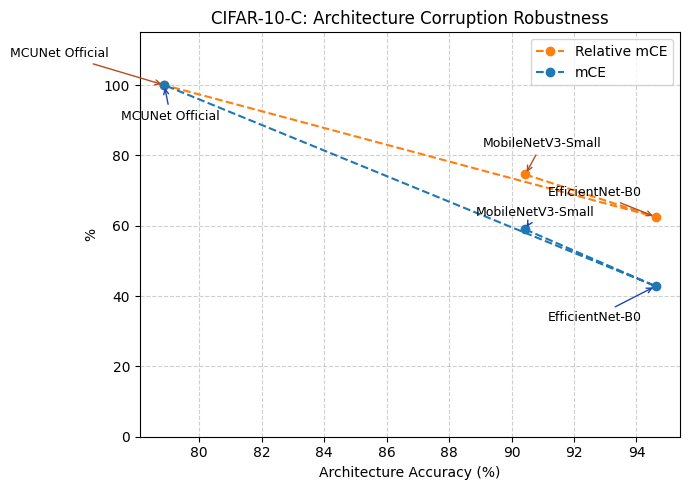

In [3]:
# =============================================================================
# CIFAR-10-C — mCE and Relative mCE (baseline: MCUNet_Official)
# =============================================================================

# 1) Clean accuracy (with automatic cache)
clean_acc_c10 = compute_clean_accuracy("CIFAR10")

# 2) Compute mCE and Relative mCE
JSONL_C10 = RESULTS_DIR / "cifar10c_baseline-MCUNet_Official_ce_results.jsonl"
BASELINE_ACC_C10 = RESULTS_DIR / "cifar10c_baseline-MCUNet_Official_baseline_acc.json"

mce_c10, rel_mce_c10 = compute_mce_and_relative_mce(
    JSONL_C10, BASELINE_ACC_C10, clean_acc_c10
)

# 3) Summary table
print(f"\n{'='*60}")
print(f"CIFAR-10-C — Baseline: {BASELINE_NAME}")
print(f"{'='*60}")
print(f"{'Model':<20s} {'Clean Acc':>10s} {'mCE (%)':>10s} {'Rel.mCE (%)':>12s}")
print("-" * 55)
for m in MODEL_NAMES:
    flag = " <- baseline" if m == BASELINE_NAME else ""
    print(f"{m:<20s} {clean_acc_c10[m]*100:>9.2f}% {mce_c10[m]:>9.2f}% {rel_mce_c10[m]:>11.2f}%{flag}")
print(f"{'='*60}")

# 4) Plot
plot_robustness(clean_acc_c10, mce_c10, rel_mce_c10, "CIFAR-10-C")


CIFAR-10 — File size comparison dos Models
Model               │    Keras │  Keras.zip │   TFLite │ TFLite.zip
─────────────────────────────────────────────────────────────────
MobileNetV3-Small    │  4.14 MB │    3.40 MB │  3.58 MB │    3.31 MB
EfficientNet-B0      │ 16.30 MB │   14.42 MB │ 15.35 MB │   14.21 MB
MCUNet Official      │  6.02 MB │    5.15 MB │  5.39 MB │    5.01 MB
Plot salvo em: cifar10_model_size_comparison.pdf


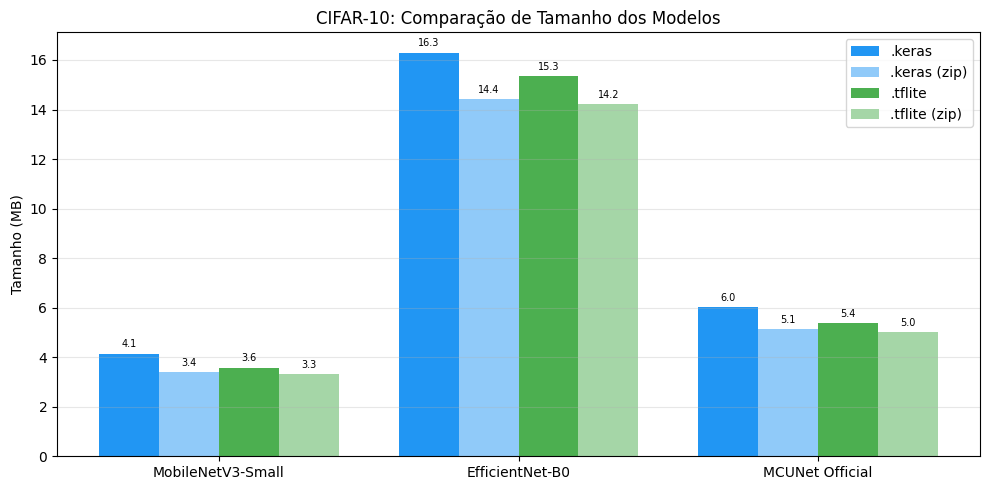

In [4]:
# =============================================================================
# CIFAR-10 — File size comparison: .keras vs .tflite vs .zip
# =============================================================================
import os, zipfile, tempfile

TFLITE_DIR = ROOT / "tflite_models"

TFLITE_FILES_C10 = {
    "MobileNetV3Small": "MobileNetV3Small_CIFAR10.tflite",
    "EfficientNetB0":   "EfficientNetB0_CIFAR10.tflite",
    "MCUNet_Official":  "MCUNet_Official_CIFAR10.tflite",  # may be missing
}

def file_size_mb(path):
    """Retorna tamanho do arquivo em MB (0.0 se não existir)."""
    p = Path(path)
    return p.stat().st_size / (1024 * 1024) if p.exists() else 0.0

def zip_size_mb(path):
    """Comprime o arquivo com ZIP (deflate) e retorna o tamanho comprimido em MB."""
    p = Path(path)
    if not p.exists():
        return 0.0
    with tempfile.NamedTemporaryFile(suffix=".zip", delete=False) as tmp:
        tmp_path = tmp.name
    try:
        with zipfile.ZipFile(tmp_path, 'w', zipfile.ZIP_DEFLATED) as zf:
            zf.write(p, p.name)
        return os.path.getsize(tmp_path) / (1024 * 1024)
    finally:
        os.remove(tmp_path)

# --- Collect file sizes ---
rows_c10 = []
for model in MODEL_NAMES:
    keras_path = KERAS_DIR / KERAS_FILES["CIFAR10"][model]
    tflite_path = TFLITE_DIR / TFLITE_FILES_C10[model]

    ks = file_size_mb(keras_path)
    ts = file_size_mb(tflite_path)
    kz = zip_size_mb(keras_path)
    tz = zip_size_mb(tflite_path)

    rows_c10.append({
        "model": model,
        "display": DISPLAY_NAMES[model],
        "keras_mb": ks,
        "tflite_mb": ts,
        "keras_zip_mb": kz,
        "tflite_zip_mb": tz,
    })

# --- Table ---
print(f"\n{'='*80}")
print(f"CIFAR-10 — model file size comparison")
print(f"{'='*80}")
print(f"{'Model':<20s} │ {'Keras':>8s} │ {'Keras.zip':>10s} │ {'TFLite':>8s} │ {'TFLite.zip':>10s}")
print("─" * 65)
for r in rows_c10:
    ks_str = f"{r['keras_mb']:.2f} MB"
    kz_str = f"{r['keras_zip_mb']:.2f} MB" if r['keras_mb'] > 0 else "N/A"
    ts_str = f"{r['tflite_mb']:.2f} MB" if r['tflite_mb'] > 0 else "N/A"
    tz_str = f"{r['tflite_zip_mb']:.2f} MB" if r['tflite_mb'] > 0 else "N/A"
    print(f"{r['display']:<20s} │ {ks_str:>8s} │ {kz_str:>10s} │ {ts_str:>8s} │ {tz_str:>10s}")
print(f"{'='*80}")

# --- Plot ---
labels = [r["display"] for r in rows_c10]
x = np.arange(len(labels))
width = 0.2

keras_vals   = [r["keras_mb"] for r in rows_c10]
kzip_vals    = [r["keras_zip_mb"] for r in rows_c10]
tflite_vals  = [r["tflite_mb"] for r in rows_c10]
tzip_vals    = [r["tflite_zip_mb"] for r in rows_c10]

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - 1.5*width, keras_vals,  width, label=".keras",      color="#2196F3")
b2 = ax.bar(x - 0.5*width, kzip_vals,   width, label=".keras (zip)", color="#90CAF9")
b3 = ax.bar(x + 0.5*width, tflite_vals, width, label=".tflite",      color="#4CAF50")
b4 = ax.bar(x + 1.5*width, tzip_vals,   width, label=".tflite (zip)",color="#A5D6A7")

ax.set_ylabel("Size (MB)")
ax.set_title("CIFAR-10: model file size comparison")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Anotações com o valor em cada barra
for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(ROOT / "figures" / "cifar10_model_size_comparison.pdf", format='pdf', bbox_inches='tight')
print("Plot saved to: cifar10_model_size_comparison.pdf")
plt.show()

Clean accuracy loaded from cache: results\cifar100_clean_accuracy.json
  MobileNetV3Small: clean_acc = 0.7301
  EfficientNetB0: clean_acc = 0.7832
  MCUNet_Official: clean_acc = 0.5868

CIFAR-100-C — Baseline: MCUNet_Official
Model                 Clean Acc    mCE (%)  Rel.mCE (%)
-------------------------------------------------------
MobileNetV3Small         73.01%     76.32%       98.36%
EfficientNetB0           78.32%     66.33%       94.75%
MCUNet_Official          58.68%    100.00%      100.00% ← baseline
Plot salvo em: cifar100c_architecture_corruption_robustness.pdf


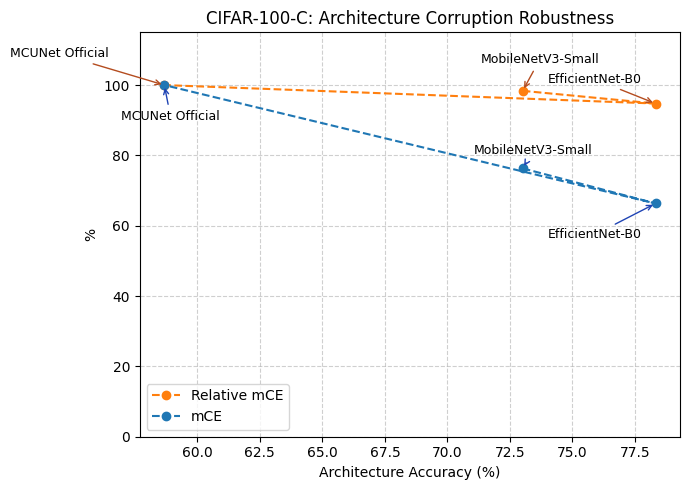

In [9]:
# =============================================================================
# CIFAR-100-C — mCE and Relative mCE (baseline: MCUNet_Official)
# =============================================================================

# 1) Clean accuracy (with automatic cache)
clean_acc_c100 = compute_clean_accuracy("CIFAR100")

# 2) Compute mCE and Relative mCE
JSONL_C100 = RESULTS_DIR / "cifar100c_baseline-MCUNet_Official_ce_results.jsonl"
BASELINE_ACC_C100 = RESULTS_DIR / "cifar100c_baseline-MCUNet_Official_baseline_acc.json"

mce_c100, rel_mce_c100 = compute_mce_and_relative_mce(
    JSONL_C100, BASELINE_ACC_C100, clean_acc_c100
)

# 3) Summary table
print(f"\n{'='*60}")
print(f"CIFAR-100-C — Baseline: {BASELINE_NAME}")
print(f"{'='*60}")
print(f"{'Model':<20s} {'Clean Acc':>10s} {'mCE (%)':>10s} {'Rel.mCE (%)':>12s}")
print("-" * 55)
for m in MODEL_NAMES:
    flag = " <- baseline" if m == BASELINE_NAME else ""
    print(f"{m:<20s} {clean_acc_c100[m]*100:>9.2f}% {mce_c100[m]:>9.2f}% {rel_mce_c100[m]:>11.2f}%{flag}")
print(f"{'='*60}")

# 4) Plot
plot_robustness(clean_acc_c100, mce_c100, rel_mce_c100, "CIFAR-100-C")


CIFAR-100 — File size comparison dos Models
Model               │    Keras │  Keras.zip │   TFLite │ TFLite.zip
─────────────────────────────────────────────────────────────────
MobileNetV3-Small    │  4.34 MB │    3.58 MB │  3.78 MB │    3.49 MB
EfficientNet-B0      │ 16.74 MB │   14.83 MB │ 15.79 MB │   14.62 MB
MCUNet Official      │  6.13 MB │    5.25 MB │  5.50 MB │    5.11 MB
Plot salvo em: cifar100_model_size_comparison.pdf


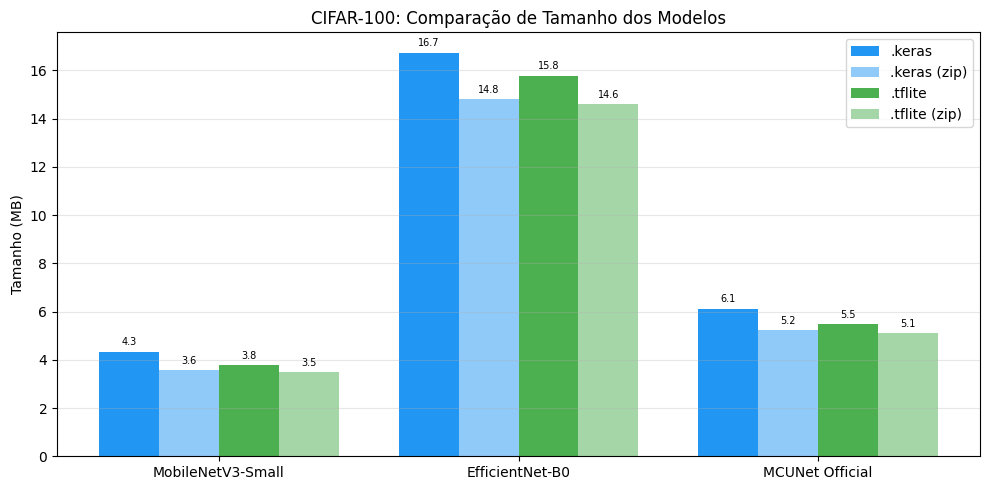

In [13]:
# =============================================================================
# CIFAR-100 — File size comparison: .keras vs .tflite vs .zip
# =============================================================================

TFLITE_FILES_C100 = {
    "MobileNetV3Small": "MobileNetV3Small_CIFAR100.tflite",
    "EfficientNetB0":   "EfficientNetB0_CIFAR100.tflite",
    "MCUNet_Official":  "MCUNet_Official_CIFAR100.tflite",  # may be missing
}

# --- Collect file sizes ---
rows_c100 = []
for model in MODEL_NAMES:
    keras_path = KERAS_DIR / KERAS_FILES["CIFAR100"][model]
    tflite_path = TFLITE_DIR / TFLITE_FILES_C100[model]

    ks = file_size_mb(keras_path)
    ts = file_size_mb(tflite_path)
    kz = zip_size_mb(keras_path)
    tz = zip_size_mb(tflite_path)

    rows_c100.append({
        "model": model,
        "display": DISPLAY_NAMES[model],
        "keras_mb": ks,
        "tflite_mb": ts,
        "keras_zip_mb": kz,
        "tflite_zip_mb": tz,
    })

# --- Table ---
print(f"\n{'='*80}")
print(f"CIFAR-100 — model file size comparison")
print(f"{'='*80}")
print(f"{'Model':<20s} │ {'Keras':>8s} │ {'Keras.zip':>10s} │ {'TFLite':>8s} │ {'TFLite.zip':>10s}")
print("─" * 65)
for r in rows_c100:
    ks_str = f"{r['keras_mb']:.2f} MB"
    kz_str = f"{r['keras_zip_mb']:.2f} MB" if r['keras_mb'] > 0 else "N/A"
    ts_str = f"{r['tflite_mb']:.2f} MB" if r['tflite_mb'] > 0 else "N/A"
    tz_str = f"{r['tflite_zip_mb']:.2f} MB" if r['tflite_mb'] > 0 else "N/A"
    print(f"{r['display']:<20s} │ {ks_str:>8s} │ {kz_str:>10s} │ {ts_str:>8s} │ {tz_str:>10s}")
print(f"{'='*80}")

# --- Plot ---
labels = [r["display"] for r in rows_c100]
x = np.arange(len(labels))
width = 0.2

keras_vals   = [r["keras_mb"] for r in rows_c100]
kzip_vals    = [r["keras_zip_mb"] for r in rows_c100]
tflite_vals  = [r["tflite_mb"] for r in rows_c100]
tzip_vals    = [r["tflite_zip_mb"] for r in rows_c100]

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - 1.5*width, keras_vals,  width, label=".keras",      color="#2196F3")
b2 = ax.bar(x - 0.5*width, kzip_vals,   width, label=".keras (zip)", color="#90CAF9")
b3 = ax.bar(x + 0.5*width, tflite_vals, width, label=".tflite",      color="#4CAF50")
b4 = ax.bar(x + 1.5*width, tzip_vals,   width, label=".tflite (zip)",color="#A5D6A7")

ax.set_ylabel("Size (MB)")
ax.set_title("CIFAR-100: model file size comparison")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(ROOT / "figures" / "cifar100_model_size_comparison.pdf", format='pdf', bbox_inches='tight')
print("Plot saved to: cifar100_model_size_comparison.pdf")
plt.show()